In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", None)

df = pd.read_csv("Day15_Executive_Hotel_Booking_EDA_Dataset.csv")
df.head()

,Booking_ID,Hotel_Type,Hotel_Location,Booking_Date,Arrival_Date,Lead_Time_Days,Weekend_Nights,Weekday_Nights,Adults,Children,Babies,Country,Market_Segment,Distribution_Channel,Is_Repeated_Guest,Previous_Cancellations,Previous_Bookings,Room_Type_Reserved,Room_Type_Assigned,Booking_Changes,Deposit_Type,Agent_ID,Company_ID,Days_In_Waiting_List,Customer_Type,Meal_Type,Total_Nights,ADR,Required_Car_Parking_Spaces,Total_Special_Requests,Satisfaction_Score,Reservation_Status,Is_Canceled,Reservation_Status_Date,Estimated_Revenue
0,HTL024548,City Hotel,London,2024-07-29,2025-07-04,340,2,2,2,0.0,0,ARE,Direct,Direct,1,0,6,H,H,0,Non Refund,103.0,NaN,5,Contract,HB,4,178.66,0,1,4.37,No-Show,1,2025-07-07,714.65
1,HTL019878,City Hotel,London,2024-05-28,2025-02-08,256,1,2,2,2.0,0,JPN,Groups,Direct,0,0,0,H,H,0,No Deposit,80.0,NaN,3,Contract,Undefined,3,125.81,0,0,3.63,Canceled,1,2025-02-09,377.43
2,HTL017377,City Hotel,Lisbon,2024-05-10,2024-06-20,41,1,1,4,0.0,0,POL,Online TA,TA/TO,0,0,0,D,D,0,No Deposit,53.0,NaN,2,Transient,FB,2,148.03,0,0,3.70,Check-Out,0,2024-06-20,296.06
3,HTL003352,City Hotel,Lisbon,2024-03-15,2024-04-07,23,0,2,2,0.0,0,CAN,Offline TA/TO,TA/TO,0,0,0,H,H,3,No Deposit,96.0,NaN,0,Contract,HB,2,166.82,0,3,3.18,Check-Out,0,2024-04-08,333.63
4,HTL012521,City Hotel,London,2024-08-21,2025-05-30,282,0,3,4,0.0,0,PRT,Direct,Direct,0,0,0,C,C,0,No Deposit,51.0,NaN,3,Group,HB,3,76.83,0,1,3.79,Check-Out,0,2025-06-01,230.50


In [3]:
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])
print("\nData types:")
print(df.dtypes)

Rows: 25180
Columns: 35

Data types:
Booking_ID                      object
Hotel_Type                      object
Hotel_Location                  object
Booking_Date                    object
Arrival_Date                    object
Lead_Time_Days                   int64
Weekend_Nights                   int64
Weekday_Nights                   int64
Adults                           int64
Children                       float64
Babies                           int64
Country                         object
Market_Segment                  object
Distribution_Channel            object
Is_Repeated_Guest                int64
Previous_Cancellations           int64
Previous_Bookings                int64
Room_Type_Reserved              object
Room_Type_Assigned              object
Booking_Changes                  int64
Deposit_Type                    object
Agent_ID                       float64
Company_ID                     float64
Days_In_Waiting_List             int64
Customer_Type              

In [2]:
df.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Booking_ID,25180,25000,HTL014830,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Hotel_Type,25180,5,City Hotel,15606,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Hotel_Location,25074,11,Dubai,3171,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Booking_Date,25180,731,2025-12-10,58,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Arrival_Date,25180,1073,2026-01-02,54,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Lead_Time_Days,25180.0,NaN,NaN,NaN,182.200556,105.604452,0.0,91.0,182.0,273.0,920.0
Weekend_Nights,25180.0,NaN,NaN,NaN,1.240429,1.063802,0.0,0.0,1.0,2.0,3.0
Weekday_Nights,25180.0,NaN,NaN,NaN,2.451072,2.031003,0.0,1.0,2.0,4.0,13.0
Adults,25180.0,NaN,NaN,NaN,2.198967,0.662379,1.0,2.0,2.0,2.0,7.0
Children,25059.0,NaN,NaN,NaN,0.372122,0.657811,0.0,0.0,0.0,1.0,6.0


## Data Quality Check


In [4]:
missing = pd.DataFrame({
    "Missing Values": df.isna().sum(),
    "Missing %": (df.isna().mean() * 100).round(2)
}).sort_values("Missing %", ascending=False)
missing[missing["Missing Values"] > 0]

,Missing Values,Missing %
Company_ID,20729,82.32
Country,466,1.85
Agent_ID,304,1.21
Meal_Type,245,0.97
Satisfaction_Score,164,0.65
Children,121,0.48
Hotel_Location,106,0.42
ADR,82,0.33


In [5]:
print("Exact duplicate rows:", df.duplicated().sum())
print("Duplicate Booking_IDs:", df["Booking_ID"].duplicated().sum())

Exact duplicate rows: 180
Duplicate Booking_IDs: 180


In [6]:
print("Hotel type values:")
print(df["Hotel_Type"].value_counts(dropna=False))

print("\nMarket segment values:")
print(df["Market_Segment"].value_counts(dropna=False))

print("\nMeal type values:")
print(df["Meal_Type"].value_counts(dropna=False))

Hotel type values:
Hotel_Type
City Hotel      15606
Resort Hotel     9454
CITY HOTEL         44
city hotel         43
City hotel         33
Name: count, dtype: int64

Market segment values:
Market_Segment
Online TA        10782
Offline TA/TO     5483
Direct            3827
Corporate         3012
Groups            1924
ONLINE TA           53
online ta           51
Online TA           48
Name: count, dtype: int64

Meal type values:
Meal_Type
BB           5027
Undefined    4978
SC           4945
HB           4939
FB           4939
NaN           245
BB             38
bb             32
 B&B           30
Unknown         7
Name: count, dtype: int64


### Cleaning



In [7]:
# Remove exact duplicate records
df = df.drop_duplicates().copy()

# Clean text columns
for col in df.select_dtypes(include="object").columns:
    df[col] = df[col].astype("string").str.strip()

# Standardise selected categorical columns
hotel_map = {
    "city hotel": "City Hotel",
    "resort hotel": "Resort Hotel"
}
market_map = {
    "online ta": "Online TA",
    "offline ta/to": "Offline TA/TO",
    "direct": "Direct",
    "corporate": "Corporate",
    "groups": "Groups"
}
meal_map = {
    "bb": "BB", "b&b": "BB", "b & b": "BB",
    "hb": "HB", "fb": "FB", "sc": "SC",
    "undefined": "Undefined", "unknown": "Unknown"
}

df["Hotel_Type"] = df["Hotel_Type"].str.lower().map(hotel_map).fillna("Unknown").astype(str)
df["Market_Segment"] = df["Market_Segment"].str.lower().map(market_map).fillna("Unknown").astype(str)
df["Meal_Type"] = df["Meal_Type"].str.lower().map(meal_map).fillna("Unknown").astype(str)

# Convert date columns
for col in ["Booking_Date", "Arrival_Date", "Reservation_Status_Date"]:
    df[col] = pd.to_datetime(df[col], errors="coerce")

# Handle missing values
for col in ["Children", "ADR", "Satisfaction_Score"]:
    df[col] = df[col].fillna(df[col].median())

for col in ["Country", "Hotel_Location", "Meal_Type"]:
    df[col] = df[col].fillna("Unknown")

for col in ["Agent_ID", "Company_ID"]:
    df[col] = df[col].fillna(0)

print("Cleaned shape:", df.shape)

Cleaned shape: (25000, 35)


In [8]:
print("Remaining missing values:", df.isna().sum().sum())
print("Remaining duplicate rows:", df.duplicated().sum())

Remaining missing values: 0
Remaining duplicate rows: 0


## Feature Preparation



In [9]:
df["Booking_Month"] = df["Booking_Date"].dt.month_name()
df["Arrival_Month"] = df["Arrival_Date"].dt.month_name()
df["Room_Changed"] = df["Room_Type_Reserved"] != df["Room_Type_Assigned"]

lead_bins = [-1, 30, 90, 180, 365, np.inf]
lead_labels = ["0-30", "31-90", "91-180", "181-365", "366+"]
df["Lead_Time_Group"] = pd.cut(df["Lead_Time_Days"], bins=lead_bins, labels=lead_labels)

df[["Booking_Date", "Arrival_Date", "Booking_Month", "Lead_Time_Group", "Room_Changed"]].head()

,Booking_Date,Arrival_Date,Booking_Month,Lead_Time_Group,Room_Changed
0,2024-07-29,2025-07-04,July,181-365,False
1,2024-05-28,2025-02-08,May,181-365,False
2,2024-05-10,2024-06-20,May,31-90,False
3,2024-03-15,2024-04-07,March,0-30,False
4,2024-08-21,2025-05-30,August,181-365,False


## Univariate Analysis



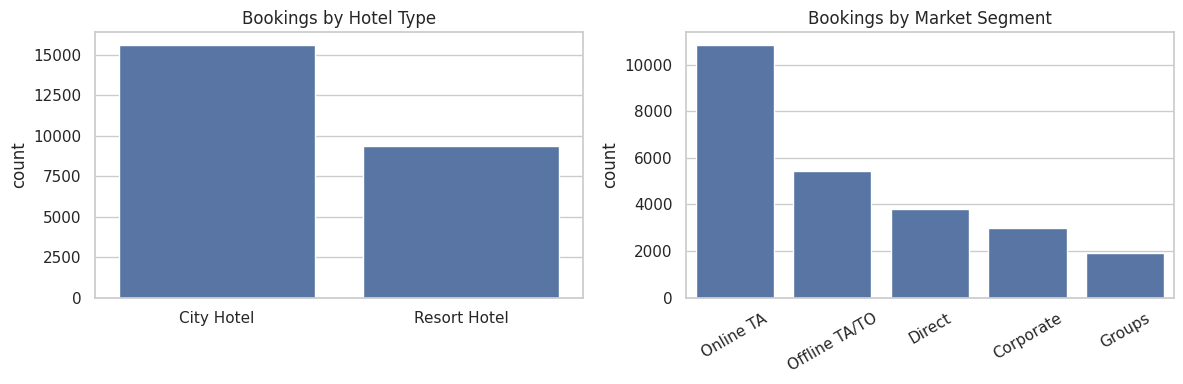

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.countplot(data=df, x="Hotel_Type", ax=axes[0])
axes[0].set_title("Bookings by Hotel Type")
axes[0].set_xlabel("")

sns.countplot(data=df, x="Market_Segment", order=df["Market_Segment"].value_counts().index, ax=axes[1])
axes[1].set_title("Bookings by Market Segment")
axes[1].tick_params(axis="x", rotation=30)
axes[1].set_xlabel("")
plt.tight_layout()
plt.show()

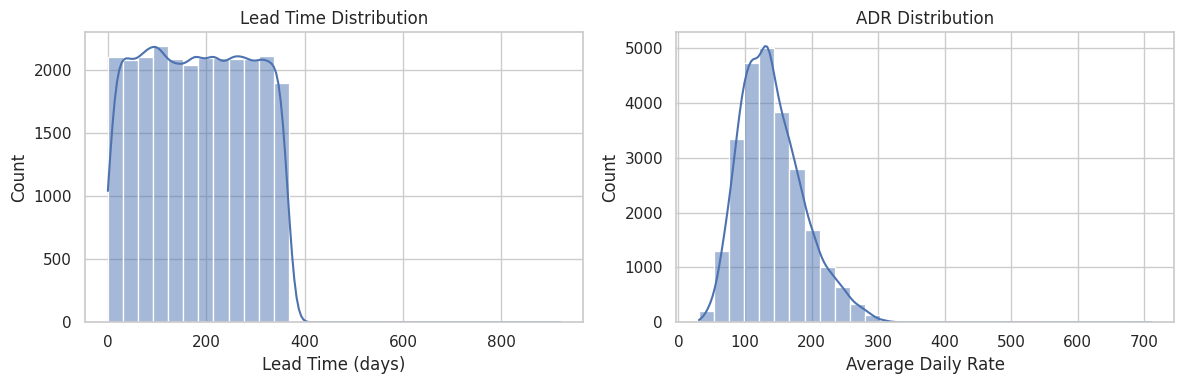

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(df["Lead_Time_Days"], bins=30, kde=True, ax=axes[0])
axes[0].set_title("Lead Time Distribution")
axes[0].set_xlabel("Lead Time (days)")

sns.histplot(df["ADR"], bins=30, kde=True, ax=axes[1])
axes[1].set_title("ADR Distribution")
axes[1].set_xlabel("Average Daily Rate")
plt.tight_layout()
plt.show()

## Cancellation Analysis



In [12]:
cancellation_rate = df["Is_Canceled"].mean() * 100
print(f"Overall cancellation rate: {cancellation_rate:.2f}%")

hotel_cancel = df.groupby("Hotel_Type")["Is_Canceled"].mean().mul(100).sort_values(ascending=False)
market_cancel = df.groupby("Market_Segment")["Is_Canceled"].mean().mul(100).sort_values(ascending=False)

print("\nCancellation rate by hotel type:")
print(hotel_cancel.round(2))

print("\nCancellation rate by market segment:")
print(market_cancel.round(2))

Overall cancellation rate: 72.18%

Cancellation rate by hotel type:
Hotel_Type
City Hotel      73.30
Resort Hotel    70.31
Name: Is_Canceled, dtype: float64

Cancellation rate by market segment:
Market_Segment
Online TA        75.10
Direct           71.22
Offline TA/TO    70.42
Groups           69.79
Corporate        67.49
Name: Is_Canceled, dtype: float64


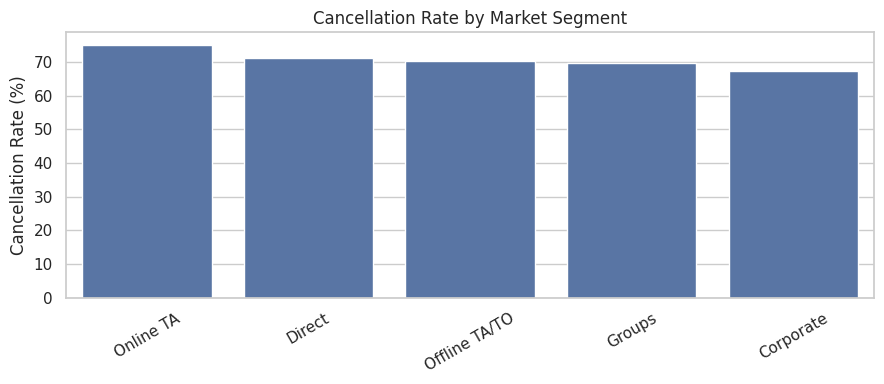

In [13]:
plt.figure(figsize=(9, 4))
sns.barplot(x=market_cancel.index, y=market_cancel.values)
plt.title("Cancellation Rate by Market Segment")
plt.ylabel("Cancellation Rate (%)")
plt.xlabel("")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

In [14]:
lead_cancel = df.groupby("Lead_Time_Group", observed=False).agg(
    Bookings=("Booking_ID", "count"),
    Cancellation_Rate=("Is_Canceled", "mean")
)
lead_cancel["Cancellation_Rate"] = (lead_cancel["Cancellation_Rate"] * 100).round(2)
lead_cancel

,Bookings,Cancellation_Rate
Lead_Time_Group,,
0-30,2105,45.13
31-90,4122,52.38
91-180,6171,66.89
181-365,12600,85.76
366+,2,50.00


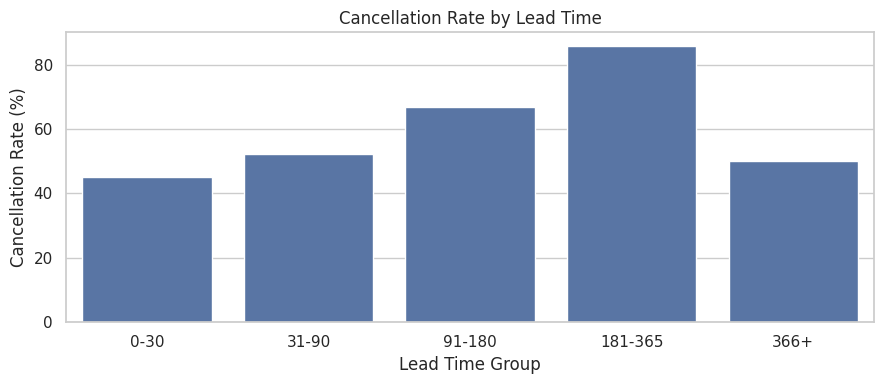

In [15]:
plt.figure(figsize=(9, 4))
sns.barplot(data=lead_cancel.reset_index(), x="Lead_Time_Group", y="Cancellation_Rate")
plt.title("Cancellation Rate by Lead Time")
plt.xlabel("Lead Time Group")
plt.ylabel("Cancellation Rate (%)")
plt.tight_layout()
plt.show()

## Revenue and Group-wise Analysis

In [16]:
hotel_summary = df.groupby("Hotel_Type").agg(
    Bookings=("Booking_ID", "count"),
    Avg_ADR=("ADR", "mean"),
    Total_Revenue=("Estimated_Revenue", "sum"),
    Cancellation_Rate=("Is_Canceled", "mean")
).sort_values("Total_Revenue", ascending=False)

hotel_summary["Cancellation_Rate"] = hotel_summary["Cancellation_Rate"] * 100
hotel_summary.round(2)

,Bookings,Avg_ADR,Total_Revenue,Cancellation_Rate
Hotel_Type,,,,
Resort Hotel,9389,173.56,7365874.95,70.31
City Hotel,15611,120.76,6018324.50,73.30


In [17]:
market_summary = df.groupby("Market_Segment").agg(
    Bookings=("Booking_ID", "count"),
    Avg_ADR=("ADR", "mean"),
    Total_Revenue=("Estimated_Revenue", "sum"),
    Cancellation_Rate=("Is_Canceled", "mean")
).sort_values("Bookings", ascending=False)

market_summary["Cancellation_Rate"] = market_summary["Cancellation_Rate"] * 100
market_summary.round(2)

,Bookings,Avg_ADR,Total_Revenue,Cancellation_Rate
Market_Segment,,,,
Online TA,10852,143.21,5932008.25,75.10
Offline TA/TO,5440,142.39,2944293.73,70.42
Direct,3808,143.25,2098049.99,71.22
Corporate,2990,134.16,1492611.61,67.49
Groups,1910,125.32,917235.87,69.79


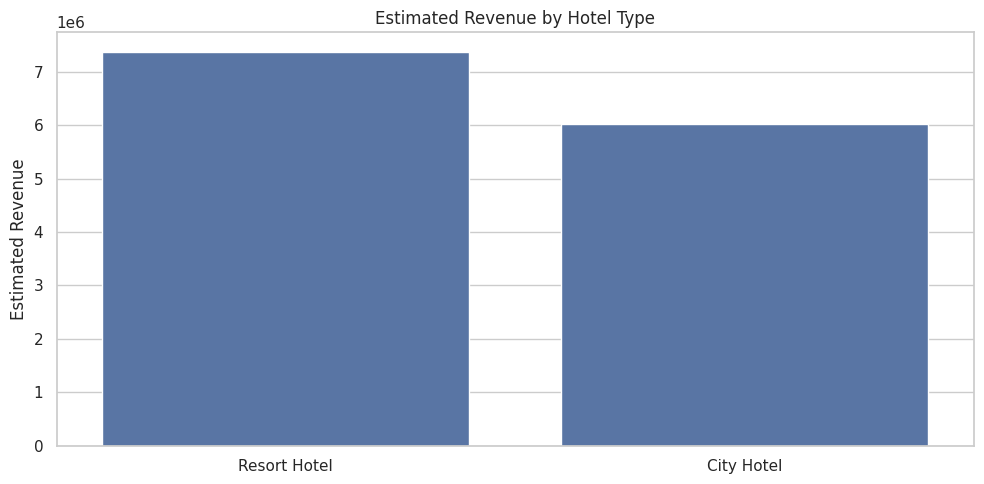

In [18]:
plt.figure(figsize=(10, 5))
sns.barplot(data=hotel_summary.reset_index(), x="Hotel_Type", y="Total_Revenue")
plt.title("Estimated Revenue by Hotel Type")
plt.xlabel("")
plt.ylabel("Estimated Revenue")
plt.tight_layout()
plt.show()

In [19]:
arrival_month = df.groupby(df["Arrival_Date"].dt.month).agg(
    Bookings=("Booking_ID", "count"),
    Cancellation_Rate=("Is_Canceled", "mean"),
    Revenue=("Estimated_Revenue", "sum")
).sort_index()
arrival_month["Cancellation_Rate"] = arrival_month["Cancellation_Rate"] * 100
arrival_month

,Bookings,Cancellation_Rate,Revenue
Arrival_Date,,,
1,2108,72.912713,943640.63
2,2003,70.743884,922646.09
3,2056,73.297665,941192.08
4,2072,72.152510,1127460.76
5,2108,71.299810,1135105.06
6,2068,73.404255,1262335.88
7,2129,70.972287,1301370.55
8,2131,73.205068,1313959.11
9,2108,72.912713,1128060.26


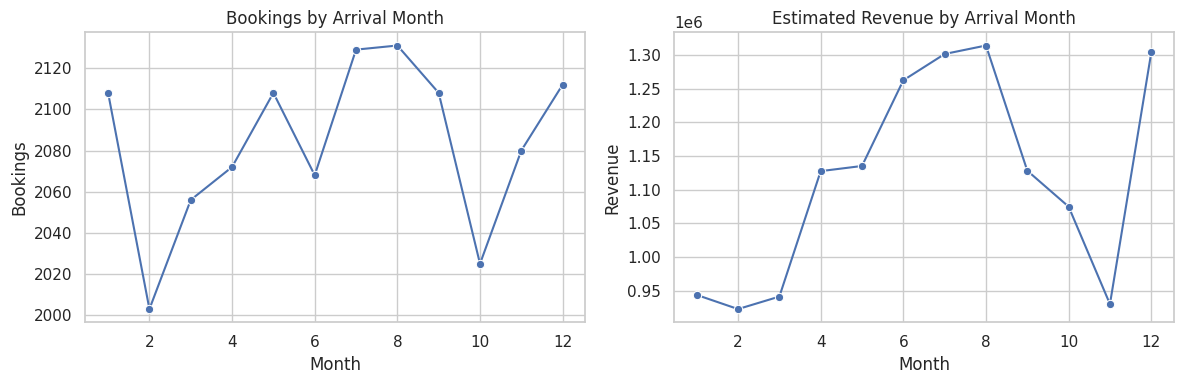

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.lineplot(data=arrival_month, x=arrival_month.index, y="Bookings", marker="o", ax=axes[0])
axes[0].set_title("Bookings by Arrival Month")
axes[0].set_xlabel("Month")

sns.lineplot(data=arrival_month, x=arrival_month.index, y="Revenue", marker="o", ax=axes[1])
axes[1].set_title("Estimated Revenue by Arrival Month")
axes[1].set_xlabel("Month")
plt.tight_layout()
plt.show()

## Customer Experience



In [21]:
request_summary = df.groupby("Total_Special_Requests").agg(
    Bookings=("Booking_ID", "count"),
    Avg_Satisfaction=("Satisfaction_Score", "mean"),
    Cancellation_Rate=("Is_Canceled", "mean")
)
request_summary["Cancellation_Rate"] *= 100
request_summary.round(2)

,Bookings,Avg_Satisfaction,Cancellation_Rate
Total_Special_Requests,,,
0,8308,3.77,72.40
1,9297,3.85,72.11
2,4883,3.93,72.00
3,1784,4.01,72.25
4,610,4.06,71.31
5,118,4.13,72.03


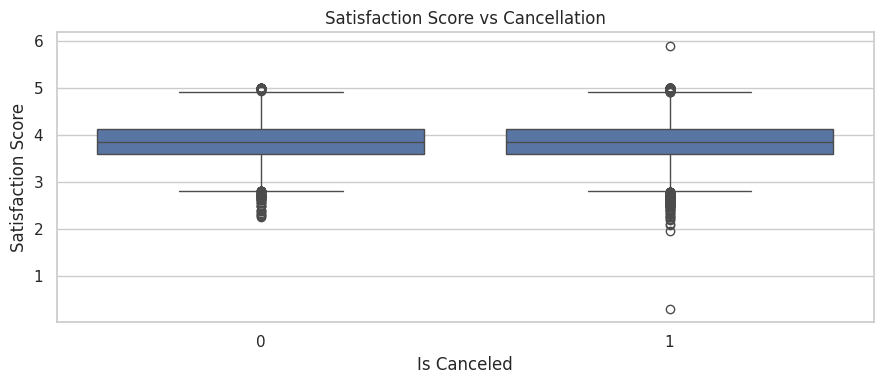

In [22]:
plt.figure(figsize=(9, 4))
sns.boxplot(data=df, x="Is_Canceled", y="Satisfaction_Score")
plt.title("Satisfaction Score vs Cancellation")
plt.xlabel("Is Canceled")
plt.ylabel("Satisfaction Score")
plt.tight_layout()
plt.show()

## Correlation Analysis



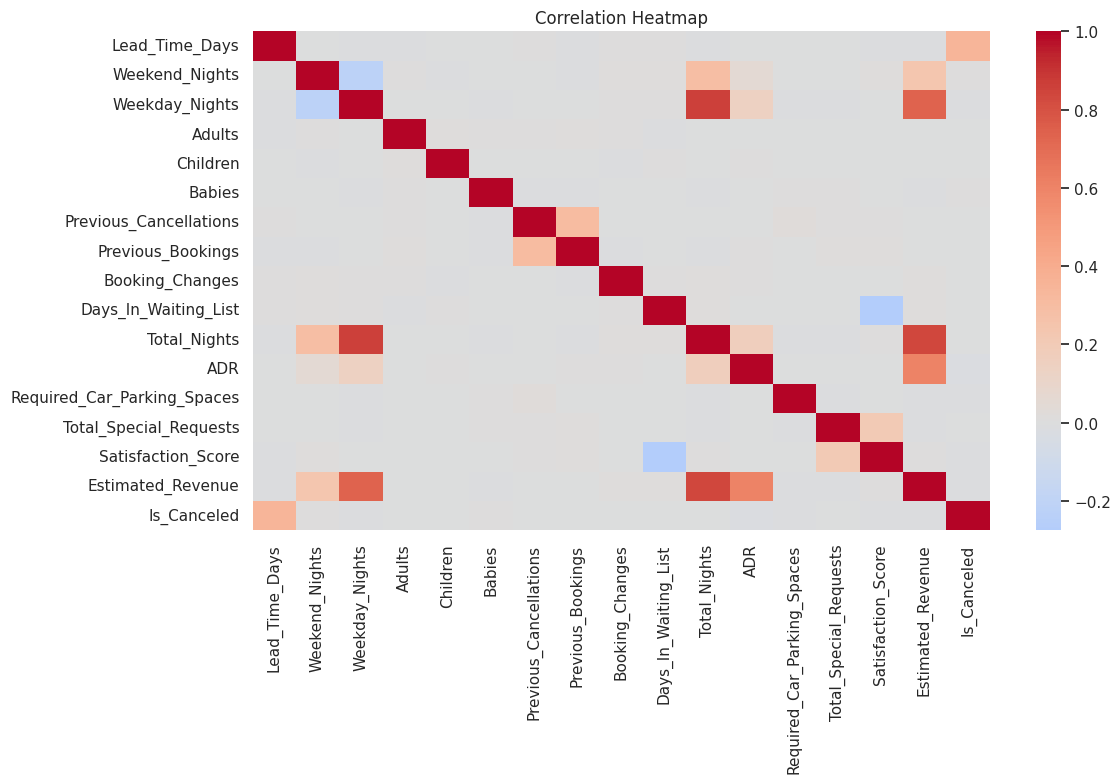

Is_Canceled                    1.000
Lead_Time_Days                 0.344
Weekend_Nights                 0.006
Babies                         0.004
Days_In_Waiting_List           0.003
Previous_Cancellations         0.002
Children                      -0.001
Previous_Bookings             -0.001
Booking_Changes               -0.002
Total_Special_Requests        -0.003
Total_Nights                  -0.005
Adults                        -0.005
Weekday_Nights                -0.007
Required_Car_Parking_Spaces   -0.010
Satisfaction_Score            -0.010
Estimated_Revenue             -0.013
ADR                           -0.017
Name: Is_Canceled, dtype: float64


In [23]:
numeric_cols = [
    "Lead_Time_Days", "Weekend_Nights", "Weekday_Nights", "Adults",
    "Children", "Babies", "Previous_Cancellations", "Previous_Bookings",
    "Booking_Changes", "Days_In_Waiting_List", "Total_Nights", "ADR",
    "Required_Car_Parking_Spaces", "Total_Special_Requests",
    "Satisfaction_Score", "Estimated_Revenue", "Is_Canceled"
]

corr = df[numeric_cols].corr()
plt.figure(figsize=(12, 8))
sns.heatmap(corr, cmap="coolwarm", center=0, annot=False)
plt.title("Correlation Heatmap")
plt.tight_layout()
plt.show()

print(corr["Is_Canceled"].sort_values(ascending=False).round(3))

## Outlier Check



In [24]:
outlier_cols = ["Lead_Time_Days", "Total_Nights", "ADR", "Estimated_Revenue", "Days_In_Waiting_List"]
outlier_report = []

for col in outlier_cols:
    q1 = df[col].quantile(0.25)
    q3 = df[col].quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    count = ((df[col] < lower) | (df[col] > upper)).sum()
    outlier_report.append([col, round(lower, 2), round(upper, 2), int(count)])

outlier_report = pd.DataFrame(outlier_report, columns=["Column", "Lower Bound", "Upper Bound", "Flagged Rows"])
outlier_report

,Column,Lower Bound,Upper Bound,Flagged Rows
0,Lead_Time_Days,-182.00,546.00,2
1,Total_Nights,-2.50,9.50,136
2,ADR,10.81,263.84,360
3,Estimated_Revenue,-529.81,1498.00,652
4,Days_In_Waiting_List,-1.50,2.50,4082


## Key Business Insights

**1. Cancellations are very high.**

Around **72% of bookings are cancelled**, so cancellations are the biggest issue in the dataset.

**2. Bookings made early are more likely to be cancelled.**

Bookings made **181–365 days before arrival** have around an **86% cancellation rate**, while bookings made within 30 days have around **45%**. This shows that longer lead time is linked to more cancellations.

**3. Online TA has the most bookings and high cancellations.**

**Online TA** has the highest number of bookings and around **75% of them are cancelled**, which is higher than most other market segments.

**4. Resort Hotels earn more per booking.**

City Hotels have more bookings, but **Resort Hotels have a higher average ADR and higher total estimated revenue** in this dataset.

**5. Customer satisfaction does not affect cancellations much.**

Satisfaction scores are quite similar for cancelled and non-cancelled bookings. This means **cancellations are more related to booking details than customer satisfaction**.


## Recommendations for Management

1. **Use better cancellation rules for early bookings.**
   For bookings made many months in advance, deposits or partial payment can help reduce cancellations.

2. **Review the Online TA channel.**
   Online TA brings many bookings but also has a high cancellation rate. The hotel can review its policies and offers for this channel.

3. **Consider lead time while planning rooms.**
   Bookings made very early should not be treated as fully confirmed because they have a higher chance of cancellation.

4. **Focus on the revenue potential of Resort Hotels.**
   Resort Hotels have a higher ADR and estimated revenue, so better pricing and upselling strategies can be used for these properties.

5. **Encourage direct bookings.**
   Simple offers or benefits for customers who book directly may help reduce dependence on channels with high cancellation rates.

6. **Track cancellations in more detail.**
   Instead of looking only at the overall cancellation rate, management should track it by **lead time, hotel type, and market segment**.

7. **Do not rely only on satisfaction scores.**
   Since satisfaction has little connection with cancellations, other factors like lead time and booking channel should be given more importance.


## Final Summary

The analysis shows that the main problem is not getting bookings, but making sure those bookings actually turn into **occupied rooms and revenue**. The biggest pattern we found is that **bookings made far in advance are more likely to be cancelled**. **Online TA** also has a high number of bookings along with a high cancellation rate.

Resort Hotels have fewer bookings than City Hotels, but they have a **higher average ADR and estimated revenue**.

Overall, the results suggest that management should look at **lead time, booking channel, and hotel type together** when making decisions about bookings, room availability, and revenue.
